# PROJET ML — CLASSIFICATION DE VIDÉOS YOUTUBE *TRENDING*

**Dataset Kaggle**: https://www.kaggle.com/datasets/datasnaek/youtube-new

**Objectif**: Développer un classificateur pour prédire si une vidéo YouTube deviendra *trending*.

> Ce notebook est conçu pour être complété. Chaque section contient des consignes détaillées et des zones de code à compléter.


## 1. Importation des librairies

**Consigne 1.1 — Importez toutes les librairies nécessaires**
- `pandas`, `numpy` pour la manipulation de données  
- `matplotlib.pyplot`, `seaborn` pour la visualisation  
- `sklearn` pour le machine learning  
- `warnings` pour supprimer les avertissements

In [2]:
# VOTRE CODE ICI - Section 1.1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import datetime as dt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pkg_resources")


## 2. Chargement et exploration des données

**Consigne 2.1 — Chargement des données**
- Chargez le fichier `USvideos.csv` avec pandas  
- Affichez les 5 premières lignes  
- Affichez les informations générales (`info()`, `shape`, `describe()`)

*Aide* :
- Utilisez `pd.read_csv()` avec `encoding='utf-8'`
- `.info()` donne les types de colonnes et valeurs non-nulles
- `.describe()` donne les statistiques descriptives

In [3]:
# VOTRE CODE ICI - Section 2.1
df = pd.read_csv('data/raw_data/USvideos.csv', encoding='utf-8')
print("Premières lignes:")
display(df.head(5))
print("\nInformations générales:")
display(df.info())
display(df.describe(include='all').transpose())

Premières lignes:


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...



Informations générales:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
video_id,40949,6351,j4KvrAUjn6c,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trending_date,40949,205,17.14.11,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,40949,6455,WE MADE OUR MOM CRY...HER DREAM CAME TRUE!,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_title,40949,2207,ESPN,203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_id,40949.0,NaN,NaN,NaN,19.972429,7.568327,1.0,17.0,24.0,25.0,43.0
publish_time,40949,6269,2018-05-18T14:00:04.000Z,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,40949,6055,[none],1535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views,40949.0,NaN,NaN,NaN,2360784.638257,7394113.759704,549.0,242329.0,681861.0,1823157.0,225211923.0
likes,40949.0,NaN,NaN,NaN,74266.702435,228885.338209,0.0,5424.0,18091.0,55417.0,5613827.0
dislikes,40949.0,NaN,NaN,NaN,3711.400889,29029.705945,0.0,202.0,631.0,1938.0,1674420.0


**Consigne 2.2 — Analyse des valeurs manquantes**  
- Comptez les valeurs manquantes par colonne  
- Identifiez les colonnes avec le plus de valeurs manquantes  
- Affichez le pourcentage de valeurs manquantes

In [4]:
# VOTRE CODE ICI - Section 2.2
missing = df["description"].isna().sum()
pct_missing = (missing / len(df)) * 100
print("Valeurs manquantes (nombre):")
display(f"{missing}")
print("\nValeurs manquantes (pourcentage):")
display(f"{pct_missing}%")

Valeurs manquantes (nombre):


'570'


Valeurs manquantes (pourcentage):


'1.3919753840142617%'

**Consigne 2.3 — Exploration des catégories**  
- Chargez le fichier JSON des catégories (`US_category_id.json`)  
- Fusionnez avec le DataFrame principal  
- Affichez la distribution des catégories

*Aide* : La structure JSON est du type:  
`{"items": [{"id": "1", "snippet": {"title": "Film & Animation"}}, ...]}`

In [5]:
# VOTRE CODE ICI - Section 2.3
import pandas as pd
import json

with open('data/raw_data/US_category_id.json') as f:
    categories_raw = json.load(f)
items = categories_raw['items']
category_dict = {int(item['id']): item['snippet']['title'] for item in items}
cat_df = pd.DataFrame(list(category_dict.items()), columns=['category_id', 'category_title'])
df_merged = df.merge(cat_df, how='left', left_on='category_id', right_on='category_id')
print("Distribution des catégories:")
display(df_merged['category_title'].value_counts().to_frame('count'))

Distribution des catégories:


,count
category_title,
Entertainment,9964
Music,6472
Howto & Style,4146
Comedy,3457
People & Blogs,3210
News & Politics,2487
Science & Technology,2401
Film & Animation,2345
Sports,2174


## 3. Nettoyage des données

**Consigne 3.1 — Nettoyage des données**
- Supprimez les doublons basés sur `video_id`  
- Gérez les valeurs manquantes dans `description` (remplacez par string vide)  
- Convertissez `publish_time` en datetime  
- Supprimez les lignes avec des valeurs aberrantes (ex: `views` négatives)

In [6]:
# VOTRE CODE ICI - Section 3.1
df_clean = df.drop_duplicates(subset='video_id').copy()
df_clean['description'] = df_clean['description'].fillna("")
df_clean['publish_time'] = pd.to_datetime(df_clean["publish_time"], errors='coerce')
df_clean = df_clean[(df_clean['views'] >= 0) & (df_clean['likes'] >= 0) & (df_clean['dislikes'] >= 0) & (df_clean['comment_count'] >= 0)]
df_clean = df_clean.dropna(subset=['publish_time'])

## 4. Feature Engineering

**Consigne 4.1 — Variables d'engagement**
** définition : https://support.google.com/youtube/answer/2991785?hl=fr**

In [7]:
# VOTRE CODE ICI - Section 4.1
eps = 1e-9
denom = df_clean['likes'] + df_clean['dislikes']
df_clean['like_ratio'] = np.where(denom > 0, df_clean['likes'] / denom, 0)
df_clean['engagement_rate'] = np.where(df_clean['views'] > 0, (df_clean['likes'] + df_clean['dislikes'] + df_clean['comment_count']) / (df_clean['views'] + eps),0)
df_clean['comments_per_view'] = np.where(df_clean['views'] > 0, df_clean['comment_count'] / (df_clean['views'] + eps), 0)
df_clean

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,like_ratio,engagement_rate,comments_per_view
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01+00:00,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,0.950970,0.102151,0.021318
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00+00:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",0.940521,0.047972,0.005252
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,0.964729,0.049994,0.002563
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04+00:00,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,0.938550,0.037836,0.006253
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,0.985181,0.072405,0.008359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40760,dS5Thrl-4Kc,18.14.06,CRAYOLA MAKEUP | HIT OR MISS?,Laura Lee,26,2018-06-12 18:55:26+00:00,"Laura88Lee|""crayola""|""crayon makeup""|""crayola ...",607422,26166,895,3517,https://i.ytimg.com/vi/dS5Thrl-4Kc/default.jpg,False,False,False,"Hey Larlees, todays video is me testing Crayol...",0.966927,0.050341,0.005790
40761,JGm9Y_hFqNk,18.14.06,First Take reacts: Kyrie Irving says contract ...,ESPN,17,2018-06-13 15:06:08+00:00,"espn|""espn live""|""boston celtics""|""kyrie irvin...",812832,7701,320,2505,https://i.ytimg.com/vi/JGm9Y_hFqNk/default.jpg,False,False,False,First Take's Stephen A. Smith and Max Kellerma...,0.960105,0.012950,0.003082
40762,6h8QgZF5Qu4,18.14.06,Drop the Mic w/ Ashton Kutcher & Sean Diddy Combs,The Late Late Show with James Corden,24,2018-06-13 05:27:27+00:00,"The Late Late Show|""Late Late Show""|""James Cor...",864189,18811,399,1074,https://i.ytimg.com/vi/6h8QgZF5Qu4/default.jpg,False,False,False,James Corden and Ashton Kutcher square off in ...,0.979230,0.023472,0.001243
40764,mpnshdmtE2Y,18.14.06,Carla Makes BA Smashburgers | From the Test Ki...,Bon Appétit,26,2018-06-12 16:03:58+00:00,"bon appetit|""burgers""|""cheeseburgers""|""how to ...",540149,14206,693,1211,https://i.ytimg.com/vi/mpnshdmtE2Y/default.jpg,False,False,False,"Ground chuck is a great all-purpose, buy-it-an...",0.953487,0.029825,0.002242


**Consigne 4.2 — Variables temporelles**

In [8]:
# VOTRE CODE ICI - Section 4.2
df_clean['publish_hour'] = df_clean['publish_time'].dt.hour
df_clean['publish_day_of_week'] = df_clean['publish_time'].dt.day_of_week
df_clean['publish_month'] = df_clean['publish_time'].dt.month
df_clean

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,comments_disabled,ratings_disabled,video_error_or_removed,description,like_ratio,engagement_rate,comments_per_view,publish_hour,publish_day_of_week,publish_month
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01+00:00,SHANtell martin,748374,57527,2966,...,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,0.950970,0.102151,0.021318,17,0,11
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00+00:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,...,False,False,False,"One year after the presidential election, John...",0.940521,0.047972,0.005252,7,0,11
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,...,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,0.964729,0.049994,0.002563,19,6,11
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04+00:00,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,...,False,False,False,Today we find out if Link is a Nickelback amat...,0.938550,0.037836,0.006253,11,0,11
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,...,False,False,False,I know it's been a while since we did this sho...,0.985181,0.072405,0.008359,18,6,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40760,dS5Thrl-4Kc,18.14.06,CRAYOLA MAKEUP | HIT OR MISS?,Laura Lee,26,2018-06-12 18:55:26+00:00,"Laura88Lee|""crayola""|""crayon makeup""|""crayola ...",607422,26166,895,...,False,False,False,"Hey Larlees, todays video is me testing Crayol...",0.966927,0.050341,0.005790,18,1,6
40761,JGm9Y_hFqNk,18.14.06,First Take reacts: Kyrie Irving says contract ...,ESPN,17,2018-06-13 15:06:08+00:00,"espn|""espn live""|""boston celtics""|""kyrie irvin...",812832,7701,320,...,False,False,False,First Take's Stephen A. Smith and Max Kellerma...,0.960105,0.012950,0.003082,15,2,6
40762,6h8QgZF5Qu4,18.14.06,Drop the Mic w/ Ashton Kutcher & Sean Diddy Combs,The Late Late Show with James Corden,24,2018-06-13 05:27:27+00:00,"The Late Late Show|""Late Late Show""|""James Cor...",864189,18811,399,...,False,False,False,James Corden and Ashton Kutcher square off in ...,0.979230,0.023472,0.001243,5,2,6
40764,mpnshdmtE2Y,18.14.06,Carla Makes BA Smashburgers | From the Test Ki...,Bon Appétit,26,2018-06-12 16:03:58+00:00,"bon appetit|""burgers""|""cheeseburgers""|""how to ...",540149,14206,693,...,False,False,False,"Ground chuck is a great all-purpose, buy-it-an...",0.953487,0.029825,0.002242,16,1,6


**Consigne 4.3 — Variables textuelles (titre)**

In [9]:
# VOTRE CODE ICI - Section 4.3
df_clean['title_length'] = df_clean['title'].str.len()
df_clean['title_word_count'] = df_clean['title'].str.count(' ')+1
df_clean['has_caps'] = df_clean['title'].apply(lambda x: any(c.isupper() for c in str(x)))
df_clean['has_numbers'] = df_clean['title'].apply(lambda x: any(c.isdigit() for c in str(x)))

## 5. Création de la variable cible

**Consigne 5.1 — Définition de `is_trending`**  
- Une vidéo est *trending* si elle a plus de vues que le 80e percentile de sa catégorie

In [10]:
# VOTRE CODE ICI - Section 5.1
df_clean['is_trending'] = (df_clean.groupby('category_id')['views']
                                  .transform(lambda x: x > x.quantile(0.8))).astype(int)
print("Distribution de la variable cible:")
display(df_clean['is_trending'].value_counts().to_frame('count'))

Distribution de la variable cible:


,count
is_trending,
0,5078
1,1273


In [18]:
fig = make_subplots(rows=2, cols=2, subplot_titles=("Nombre de vues", "Nombre de commentaires", "Nombre de likes", "Nombre de dislikes"))

fig.add_trace(go.Scatter(y=df_clean["views"]), row=1, col=1)
fig.add_trace(go.Scatter(y=df_clean['likes']), row=2, col=1)
fig.add_trace(go.Scatter(y=df_clean['dislikes']), row=2, col=2)
fig.add_trace(go.Scatter(y=df_clean['comment_count']), row=1, col=2)

fig.update_layout(showlegend=False)
fig.update_yaxes(title_text="Total")

fig.show()

## 6. Préparation des données pour l'entraînement

**Consignes 6.1 & 6.2 — Sélection des features & split test/test**

In [ ]:
from sklearn import ensemble as es
from sklearn import metrics as me
from sklearn import preprocessing as pp
from sklearn import model_selection as ms

In [ ]:
# VOTRE CODE ICI - Section 6.1 et 6.2
features = ['views', 'likes', 'dislikes', 'comment_count',
            'like_ratio', 'engagement_rate', 'title_length', 'publish_hour', 'category_id']
X = df_clean[features].copy()
y = df_clean['is_trending'].copy()

X_train, X_test, y_train, y_test = ms.train_test_split(X, y, test_size=0.20, random_state=42)

**Consigne 6.3 — Normalisation des données (StandardScaler)**

In [ ]:
# VOTRE CODE ICI - Section 6.3
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train['views'] = scaler.fit_transform(X_train[['views']])
X_train['likes'] = scaler.fit_transform(X_train[['likes']])
X_train['dislikes'] = scaler.fit_transform(X_train[['dislikes']])
X_train['comment_count'] = scaler.fit_transform(X_train[['comment_count']])
X_train['like_ratio'] = scaler.fit_transform(X_train[['like_ratio']])
X_train['engagement_rate'] = scaler.fit_transform(X_train[['engagement_rate']])
X_train['title_length'] = scaler.fit_transform(X_train[['title_length']])
X_train['publish_hour'] = scaler.fit_transform(X_train[['likes']])

X_test['views'] = scaler.fit_transform(X_test[['views']])
X_test['likes'] = scaler.fit_transform(X_test[['likes']])
X_test['dislikes'] = scaler.fit_transform(X_test[['dislikes']])
X_test['comment_count'] = scaler.fit_transform(X_test[['comment_count']])
X_test['like_ratio'] = scaler.fit_transform(X_test[['like_ratio']])
X_test['engagement_rate'] = scaler.fit_transform(X_test[['engagement_rate']])
X_test['title_length'] = scaler.fit_transform(X_test[['title_length']])
X_test['publish_hour'] = scaler.fit_transform(X_test[['likes']])

## 7. Modèle 1 — Random Forest

**Consigne 7.1 — Entraînement**

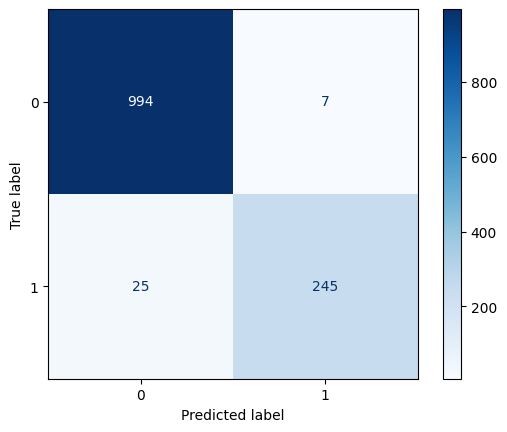

In [ ]:
# VOTRE CODE ICI - Section 7.1
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

cm = me.confusion_matrix(y_test, rf_predictions)
disp = me.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

**Consigne 7.2 — Évaluation**

In [ ]:
# VOTRE CODE ICI - Section 7.2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Random Forest - Résultats:")
print(f"Accuracy: {accuracy_score(y_test, rf_predictions):.4f}")
print(f"Precision: {precision_score(y_test, rf_predictions):.4f}")
print(f"Recall: {recall_score(y_test, rf_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_predictions):.4f}")

feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop 10 variables importantes:")
display(feature_importance.head(10))

Random Forest - Résultats:
Accuracy: 0.9748
Precision: 0.9722
Recall: 0.9074
F1-Score: 0.9387

Top 10 variables importantes:


,feature,importance
0,views,0.473160
2,dislikes,0.111747
7,publish_hour,0.099269
8,category_id,0.084652
3,comment_count,0.078530
1,likes,0.064187
5,engagement_rate,0.053631
4,like_ratio,0.018559
6,title_length,0.016265


## 8. Modèle 2 — Support Vector Machine (SVM)

**Consigne 8.1 — Entraînement (utiliser données normalisées)**

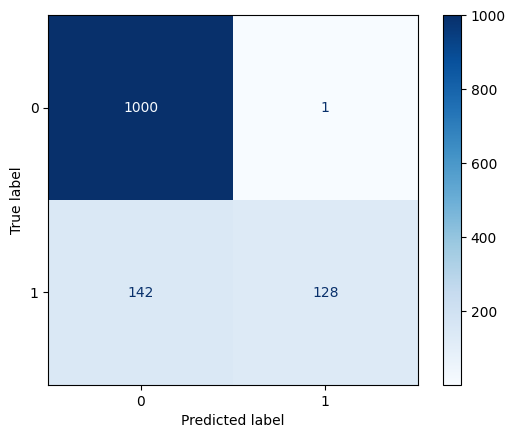

In [ ]:
# VOTRE CODE ICI - Section 8.1
from sklearn.svm import SVC
svc_model = SVC()
svc_model.fit(X_train, y_train)
svc_predictions = svc_model.predict(X_test)

cm = me.confusion_matrix(y_test, svc_predictions)
disp = me.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

**Consigne 8.2 — Évaluation**

In [ ]:
# VOTRE CODE ICI - Section 8.2
print("SVM - Résultats:")
print(f"Accuracy: {accuracy_score(y_test, svc_predictions):.4f}")
print(f"Precision: {precision_score(y_test, svc_predictions):.4f}")
print(f"Recall: {recall_score(y_test, svc_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, svc_predictions):.4f}")

# feature_importance = pd.DataFrame({
#     'feature': X_test.columns,
#     'importance': svc_model.feature_importances_
# }).sort_values('importance', ascending=False)
# print("\nTop 10 variables importantes:")
# display(feature_importance.head(10))


SVM - Résultats:
Accuracy: 0.8875
Precision: 0.9922
Recall: 0.4741
F1-Score: 0.6416


## 9. Modèle 3 — Gradient Boosting (XGBoost)

**Consigne 9.1 — Entraînement**

In [ ]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=100, 
                          max_depth=6, 
                          learning_rate=0.1, 
                          subsample=1.0, 
                          colsample_bytree=1.0, 
                          random_state=42, 
                          n_jobs=-1, 
                          eval_metric='logloss')

xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

**Consigne 9.2 — Évaluation**

In [ ]:
# VOTRE CODE ICI - Section 9.2
print("XGBoost - Résultats:")
print(f"Accuracy: {accuracy_score(y_test, xgb_predictions):.4f}")
print(f"Precision: {precision_score(y_test, xgb_predictions):.4f}")
print(f"Recall: {recall_score(y_test, xgb_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, xgb_predictions):.4f}")

XGBoost - Résultats:
Accuracy: 0.9906
Precision: 0.9924
Recall: 0.9630
F1-Score: 0.9774


## 10. Modèle 4 — Réseau de Neurones (MLPClassifier)

**Consigne 10.1 — Entraînement (données normalisées)**

In [ ]:
# VOTRE CODE ICI - Section 10.1
from sklearn.neural_network import MLPClassifier
nn_model = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=1000, random_state=42)
nn_model.fit(X_train, y_train)
nn_predictions = nn_model.predict(X_test)

**Consigne 10.2 — Évaluation**

In [ ]:
# VOTRE CODE ICI - Section 10.2
print("Réseau de Neurones - Résultats:")
print(f"Precision: {precision_score(y_test, nn_predictions):.4f}")
print(f"Recall: {recall_score(y_test, nn_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, nn_predictions):.4f}")
# Nombre d'itérations
print(nn_model.n_iter_," itérations")

Réseau de Neurones - Résultats:
Precision: 0.8812
Recall: 0.8519
F1-Score: 0.8663
127  itérations


## 11. Comparaison des modèles

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.974823,0.972222,0.907407,0.938697
1,SVM,0.887490,0.992248,0.474074,0.641604
2,XGBoost,0.990559,0.992366,0.962963,0.977444
3,Neural Network,0.944138,0.881226,0.851852,0.866290


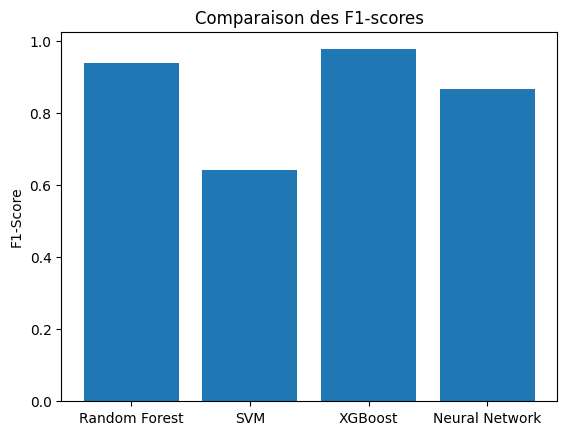

In [ ]:
# VOTRE CODE ICI - Section 11.1

results = []

results.append({'Model': 'Random Forest', 'Accuracy': accuracy_score(y_test, rf_predictions), 'Precision': precision_score(y_test, rf_predictions), 'Recall': recall_score(y_test, rf_predictions), 'F1-Score': f1_score(y_test, rf_predictions)})
results.append({'Model': 'SVM', 'Accuracy': accuracy_score(y_test, svc_predictions), 'Precision': precision_score(y_test, svc_predictions), 'Recall': recall_score(y_test, svc_predictions), 'F1-Score': f1_score(y_test, svc_predictions)})
results.append({'Model': 'XGBoost', 'Accuracy': accuracy_score(y_test, xgb_predictions), 'Precision': precision_score(y_test, xgb_predictions), 'Recall': recall_score(y_test, xgb_predictions), 'F1-Score': f1_score(y_test, xgb_predictions)})
results.append({'Model': 'Neural Network', 'Accuracy': accuracy_score(y_test, nn_predictions), 'Precision': precision_score(y_test, nn_predictions), 'Recall': recall_score(y_test, nn_predictions), 'F1-Score': f1_score(y_test, nn_predictions)})
results_df = pd.DataFrame(results)
display(results_df)
# Graphique comparatif des F1-scores (optionnel)

plt.figure()
plt.bar(results_df['Model'], results_df['F1-Score'])
plt.title('Comparaison des F1-scores')
plt.ylabel('F1-Score')
plt.show()

## 12. Validation croisée

In [ ]:
# VOTRE CODE ICI - Section 12.1
warnings.filterwarnings("ignore", category=UserWarning, module="pkg_resources")
from sklearn.model_selection import cross_val_score
# Exemple avec Random Forest (remplacez par votre meilleur modèle)
scores = cross_val_score(xgb_model, X, y, cv=5, scoring='f1', n_jobs=-1)
print(f"Validation croisée - F1-Score: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/pyth

Validation croisée - F1-Score: 0.9819 (+/- 0.0172)


## 13. Optimisation des hyperparamètres (Grid Search)

In [ ]:
# VOTRE CODE ICI - Section 13.1

warnings.filterwarnings("ignore", category=UserWarning, module="pkg_resources")
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'learning_rate': [0.5, 0.1, 0.01]
}
grid_search = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Meilleurs paramètres:", grid_search.best_params_)
print("Meilleur score CV:", grid_search.best_score_)
best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test)

Meilleurs paramètres: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100}
Meilleur score CV: 0.9753672699455832


## 14. Analyse des erreurs

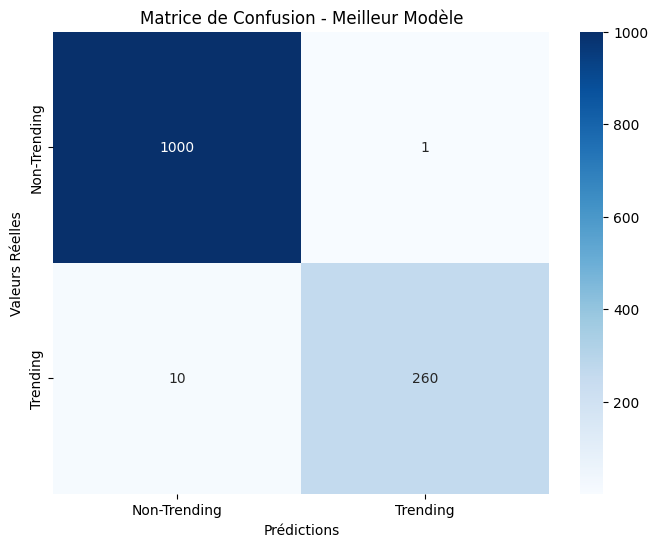

In [ ]:
# VOTRE CODE ICI - Section 14.1
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Exemple: matrice de confusion pour le meilleur modèle (remplacez best_rf_pred)
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Trending', 'Trending'],
            yticklabels=['Non-Trending', 'Trending'])
plt.title('Matrice de Confusion - Meilleur Modèle')
plt.ylabel('Valeurs Réelles')
plt.xlabel('Prédictions')
plt.show()

In [ ]:
# VOTRE CODE ICI - Section 14.2
# Identifier des exemples mal classifiés (adapter selon le modèle choisi)
errors_mask = (y_test != best_pred)
error_indices = X_test[errors_mask].index
print("Exemples de vidéos mal classifiées:")
for idx in list(error_indices)[:5]:
    real_label = y_test.loc[idx]
    predicted_label = best_pred[list(error_indices).index(idx)]  # à adapter si nécessaire
    print(f"Index {idx}: Réel={real_label}, Prédit={predicted_label}")

Exemples de vidéos mal classifiées:
Index 4018: Réel=1, Prédit=0
Index 20974: Réel=1, Prédit=0
Index 6807: Réel=1, Prédit=0
Index 16598: Réel=1, Prédit=0
Index 14804: Réel=1, Prédit=0


## 15. Sauvegarde & conclusions

In [ ]:
# VOTRE CODE ICI - Section 15.1
import joblib
# Remplacez 'best_rf' / 'scaler' par vos objets
from sklearn.pipeline import Pipeline

joblib.dump(best_model, 'best_youtube_classifier.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')

# Crée un pipeline : d'abord le scaler, puis le modèle
pipeline = Pipeline([('scaler', scaler),('classifier', best_model)])

joblib.dump(pipeline, 'youtube_pipeline.pkl')
print("Modèle et scaler sauvegardés avec succès!")

Modèle et scaler sauvegardés avec succès!


### Conclusions à rédiger

1. **Meilleur modèle**  
   - Modèle: XGBoost Classifier 
   - Performances: Très bonnes, proches de 1
   - Raisons: Excellente performances

2. **Variables les plus importantes**  
   - Views

3. **Limitations**  
   - Attention à l'overfitting

4. **Améliorations suggérées**  
   - L'entraîner sur un jeu de données plus conséquent

5. **Apprentissages**  
   - 

---
## Guide de testing pour les étudiants

**Comment tester vos implémentations :**
1. **Vérifications de base** : `.shape`, `.info()`, `.head()`  
2. **Validation des features** : pas de NaN, ratios entre 0 et 1, plages temporelles correctes  
3. **Validation des modèles** : prédictions binaires {0,1}, longueurs cohérentes, comparaisons rigoureuses  
4. **Tests de cohérence** : scores réalistes, F1 entre précision et rappel, impact de la normalisation  
5. **Debugging** : augmenter `max_iter` si nécessaire, vérifier entrées/sorties et dimensions